POLINOMIO ENCONTRADO
a = -820.74825930
b = -4887.32970153
d = 25619.14940736

Polinomio:
y = (-820.74825930)x³ + (-4887.32970153)x² + (25619.14940736)

Error relativo promedio = 0.04100341745571007
Error relativo máximo   = 0.08224789001874533


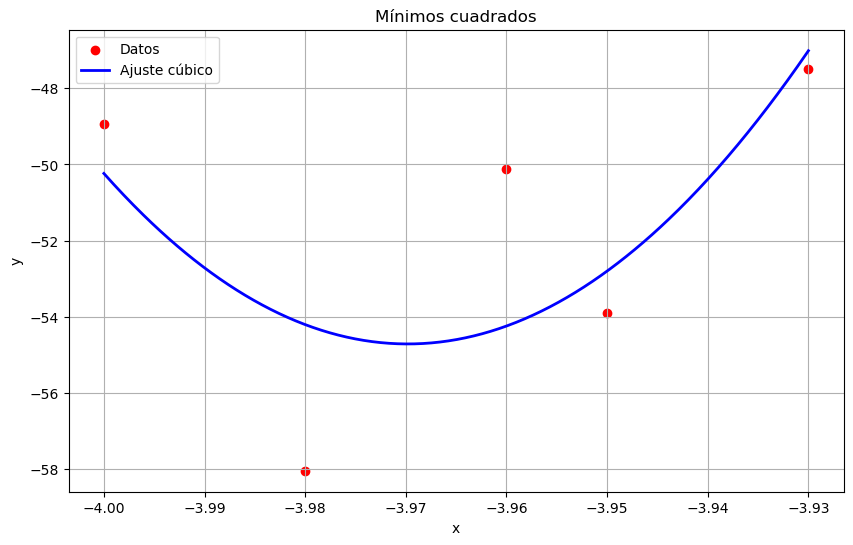

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# DERIVADAS PARCIALES
# Modelo:
# y = a*x^3 + b*x^2 + d
# ==========================================================

def der_parcial_a(xs, ys):
    return (
        np.sum(xs**6),
        np.sum(xs**5),
        np.sum(xs**3),
        np.sum(xs**3 * ys)
    )

def der_parcial_b(xs, ys):
    return (
        np.sum(xs**5),
        np.sum(xs**4),
        np.sum(xs**2),
        np.sum(xs**2 * ys)
    )

def der_parcial_d(xs, ys):
    return (
        np.sum(xs**3),
        np.sum(xs**2),
        len(xs),
        np.sum(ys)
    )

# ==========================================================
# AJUSTE POR MÍNIMOS CUADRADOS
# ==========================================================

def ajustar_min_cuadrados_modificado(xs, ys, derivadas):

    A = []
    B = []

    for f in derivadas:
        fila = f(xs, ys)
        A.append(fila[:-1])
        B.append(fila[-1])

    A = np.array(A, dtype=float)
    B = np.array(B, dtype=float)

    parametros = np.linalg.solve(A, B)

    return parametros

# ==========================================================
# CONJUNTO DE DATOS
# ==========================================================
# REEMPLAZA ESTE EJEMPLO POR EL CONJUNTO DE DATOS 1

x = np.array([
    -4.00,
    -3.98,
    -3.96,
    -3.95,
    -3.93
], dtype=float)

y = np.array([
    -48.95,
    -58.04,
    -50.12,
    -53.90,
    -47.49
], dtype=float)

# ==========================================================
# AJUSTE
# ==========================================================

a, b, d = ajustar_min_cuadrados_modificado(
    x,
    y,
    [
        der_parcial_a,
        der_parcial_b,
        der_parcial_d
    ]
)

print("="*50)
print("POLINOMIO ENCONTRADO")
print("="*50)
print(f"a = {a:.8f}")
print(f"b = {b:.8f}")
print(f"d = {d:.8f}")

print("\nPolinomio:")

print(f"y = ({a:.8f})x³ + ({b:.8f})x² + ({d:.8f})")

# ==========================================================
# PREDICCIÓN
# ==========================================================

y_pred = a*x**3 + b*x**2 + d

# ==========================================================
# ERRORES
# ==========================================================

errores = np.abs((y_pred - y) / y)

e_avg = np.mean(errores)
e_max = np.max(errores)

print("\nError relativo promedio =", e_avg)
print("Error relativo máximo   =", e_max)

# ==========================================================
# GRÁFICA
# ==========================================================

xx = np.linspace(np.min(x), np.max(x), 500)
yy = a*xx**3 + b*xx**2 + d

plt.figure(figsize=(10,6))

plt.scatter(x, y,
            color='red',
            label='Datos')

plt.plot(xx, yy,
         color='blue',
         linewidth=2,
         label='Ajuste cúbico')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Mínimos cuadrados")
plt.grid(True)
plt.legend()

plt.show()